## PIPELINE STRUCTRE of Any Data Science Project
Importing Libraries, 
Loading dataset, 
Data processing, 
Exploratory data analysis, 
Feature selection, 
Modelling data preperation into training and testing, 
Model building, 
Model evalution, 
Hyperparameter tuning / further enhancing and evaluation model

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("../data/My Uber Drives - 2016.csv")
df

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [6]:
df.columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='str')

In [7]:
df.columns = df.columns.str.replace('*','')
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='str')

In [8]:
df.dropna(how='all', subset = ['END_DATE', 'CATEGORY', 'START', 'STOP', 'PURPOSE'], inplace = True)
df.isnull().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [9]:
(df['PURPOSE'].isnull().sum() / df.shape[0]) * 100

np.float64(43.46320346320346)

In [10]:
df.shape[1]

7

In [11]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

In [12]:
df['PURPOSE'] = df['PURPOSE'].ffill()
df['PURPOSE']

0        Meal/Entertain
1        Meal/Entertain
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1150            Meeting
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
Name: PURPOSE, Length: 1155, dtype: str

In [13]:
df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [14]:
df.head()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,Meal/Entertain
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [15]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors = 'coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors = 'coerce')
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Meal/Entertain
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1155 non-null   datetime64[us]
 1   END_DATE    1155 non-null   datetime64[us]
 2   CATEGORY    1155 non-null   str           
 3   START       1155 non-null   str           
 4   STOP        1155 non-null   str           
 5   MILES       1155 non-null   float64       
 6   PURPOSE     1155 non-null   str           
dtypes: datetime64[us](2), float64(1), str(4)
memory usage: 107.9 KB


In [17]:
# To find top 10 starting point of the trip
start_points = df['START'].value_counts()
start_points.head(10)

START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               37
Lahore               36
Raleigh              28
Kar?chi              27
Apex                 17
Name: count, dtype: int64

<Axes: >

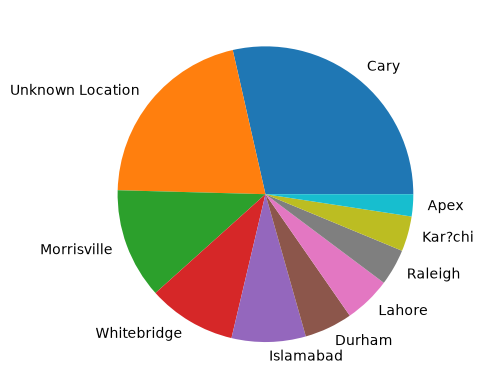

In [18]:
start_points.head(10).plot(kind = 'pie')

In [19]:
# To find least booked start points
df['START'].value_counts().tail(10)

START
Tenderloin        1
College Avenue    1
South Berkeley    1
Mountain View     1
El Cerrito        1
Krendle Woods     1
Wake Co.          1
Fuquay-Varina     1
Katunayake        1
Gampaha           1
Name: count, dtype: int64

<Axes: >

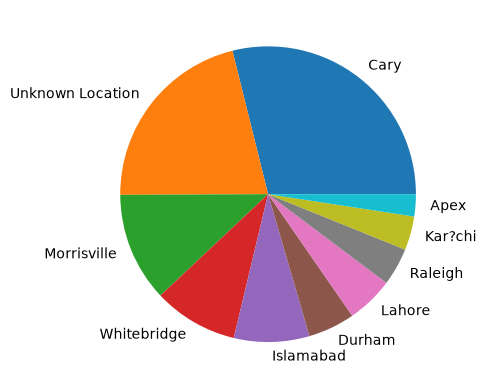

In [20]:
# To find Top most stop points
stop_points = df['STOP'].value_counts()
stop_points.head(10).plot(kind = 'pie')

In [21]:
# To find least preffered stop points
stop_points.tail(10)

STOP
Tenderloin            1
College Avenue        1
Southwest Berkeley    1
South Berkeley        1
Mountain View         1
El Cerrito            1
Wake Co.              1
Fuquay-Varina         1
Gampaha               1
Ilukwatta             1
Name: count, dtype: int64

<Axes: xlabel='MILES'>

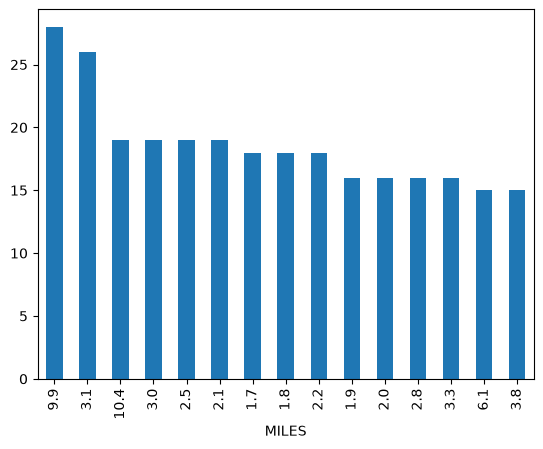

In [22]:
# Pattern in miles travelled
# Conlusion on purpose of rides
# Round trip theory
# Duration
df['MILES'].value_counts().head(15).plot(kind = 'bar')

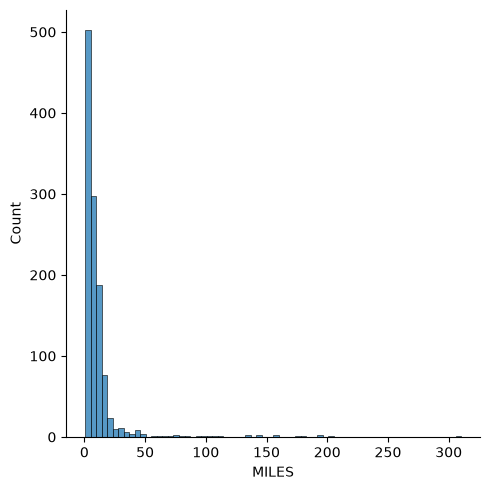

In [23]:
sns.displot(df['MILES'])

<Axes: xlabel='PURPOSE', ylabel='count'>

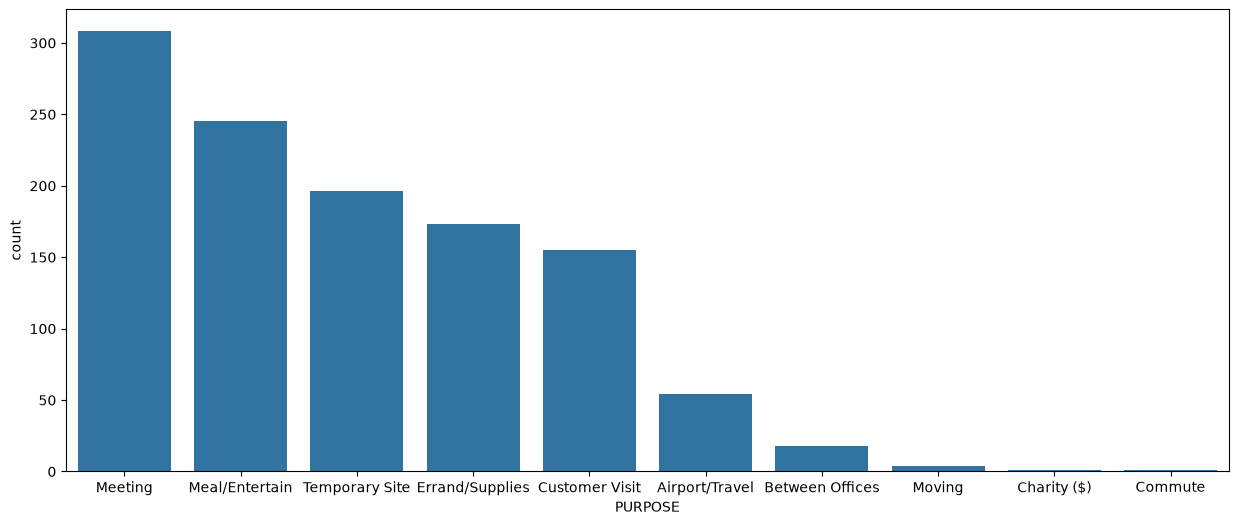

In [24]:
plt.figure(figsize=(15, 6))

# Map 'PURPOSE' to the x-axis to make the bars vertical
sns.countplot(data=df, x='PURPOSE', order=df['PURPOSE'].value_counts().index)

In [25]:
df.groupby(['START'])['START_DATE'].count()

START
Agnew               4
Almond              1
Apex               17
Arabi               1
Arlington           1
                   ..
West University     2
Weston              2
Westpark Place     17
Whitebridge        68
Winston Salem       1
Name: START_DATE, Length: 177, dtype: int64

In [26]:
df.describe()

,START_DATE,END_DATE,MILES
count,1155,1155,1155.000000
mean,2016-07-16 23:44:33.402597,2016-07-17 00:07:48,10.566840
min,2016-01-01 21:11:00,2016-01-01 21:17:00,0.500000
25%,2016-04-01 02:10:00,2016-04-01 02:35:00,2.900000
50%,2016-07-21 17:17:00,2016-07-21 17:23:00,6.000000
75%,2016-10-27 21:06:30,2016-10-27 21:21:00,10.400000
max,2016-12-31 22:08:00,2016-12-31 23:51:00,310.300000
std,NaN,NaN,21.579106


In [27]:
df.groupby(['START', 'STOP'])['MILES'].mean().reset_index().sort_values('MILES', ascending = False)

,START,STOP,MILES
173,Latta,Jacksonville,310.3
143,Jacksonville,Kissimmee,201.0
11,Asheville,Mebane,195.9
204,Morrisville,Banner Elk,195.3
27,Boone,Cary,180.2
...,...,...,...
184,Medical Centre,Tudor City,0.7
297,Sunnyside,Ingleside,0.7
56,Central,West Berkeley,0.6
155,Katunayaka,Katunayaka,0.5


In [28]:
df['MINUTES'] = df.END_DATE - df.START_DATE
df['MINUTES'].head()

0   0 days 00:06:00
1   0 days 00:12:00
2   0 days 00:13:00
3   0 days 00:14:00
4   0 days 01:07:00
Name: MINUTES, dtype: timedelta64[us]

In [29]:
def rounds(x) :
    if x['START'] == x['STOP'] :
        return 'Yes'
    else :
        return 'No'


In [30]:
df['RoundTrips'] = df.apply(rounds, axis = 1)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,MINUTES,RoundTrips
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,0 days 00:06:00,Yes
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Meal/Entertain,0 days 00:12:00,Yes
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,0 days 00:13:00,Yes
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,0 days 00:14:00,Yes
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,0 days 01:07:00,No
...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,0 days 00:07:00,Yes
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,0 days 00:18:00,No
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,0 days 00:35:00,Yes
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,0 days 00:18:00,No


<Axes: xlabel='RoundTrips', ylabel='count'>

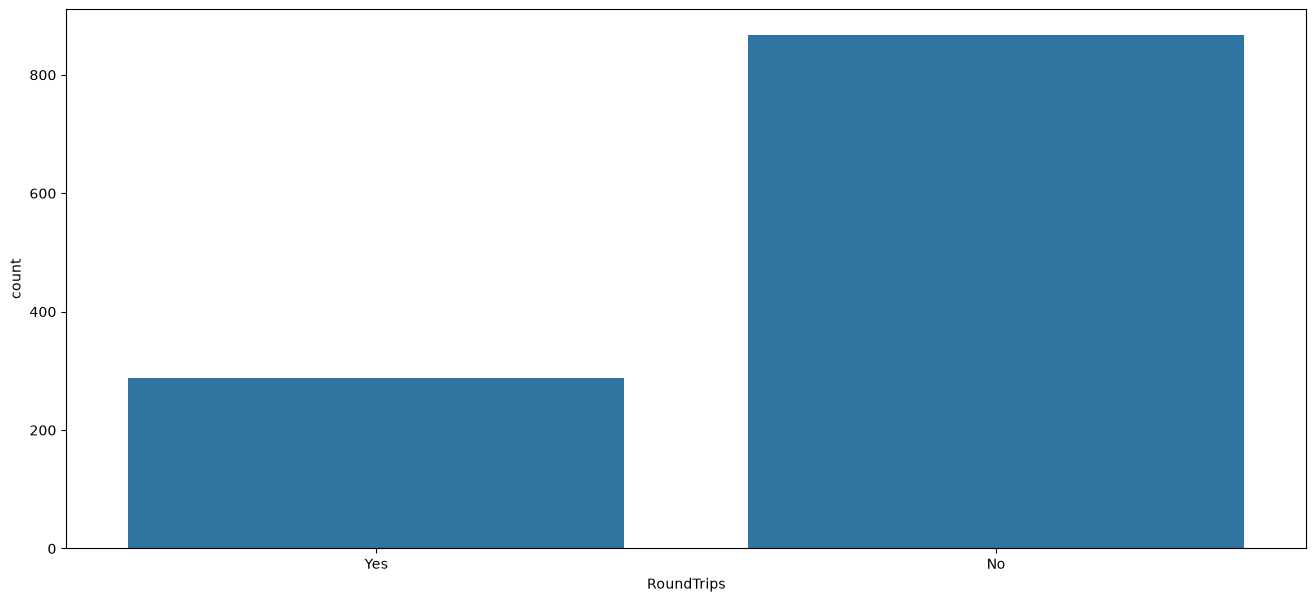

In [31]:
plt.figure(figsize = (16, 7))
sns.countplot(data = df, x = 'RoundTrips')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Meal/Entertain'),
  Text(1, 0, 'Errand/Supplies'),
  Text(2, 0, 'Meeting'),
  Text(3, 0, 'Customer Visit'),
  Text(4, 0, 'Temporary Site'),
  Text(5, 0, 'Between Offices'),
  Text(6, 0, 'Charity ($)'),
  Text(7, 0, 'Commute'),
  Text(8, 0, 'Moving'),
  Text(9, 0, 'Airport/Travel')])

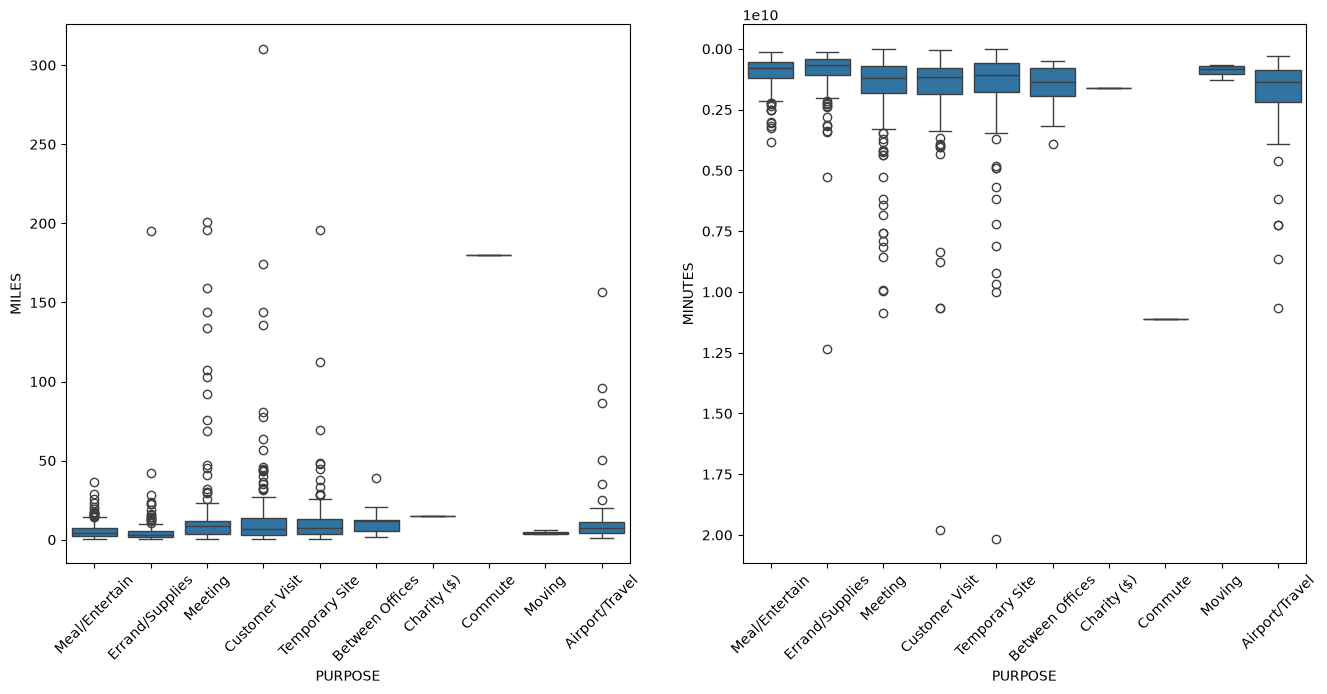

In [32]:
plt.figure(figsize = (16, 7))
plt.subplot(1, 2, 1)
sns.boxplot(data = df, x = 'PURPOSE', y = 'MILES')
plt.xticks(rotation = 45)
plt.subplot(1, 2, 2)
sns.boxplot(data = df, x = 'PURPOSE', y = 'MINUTES')
plt.xticks(rotation = 45)

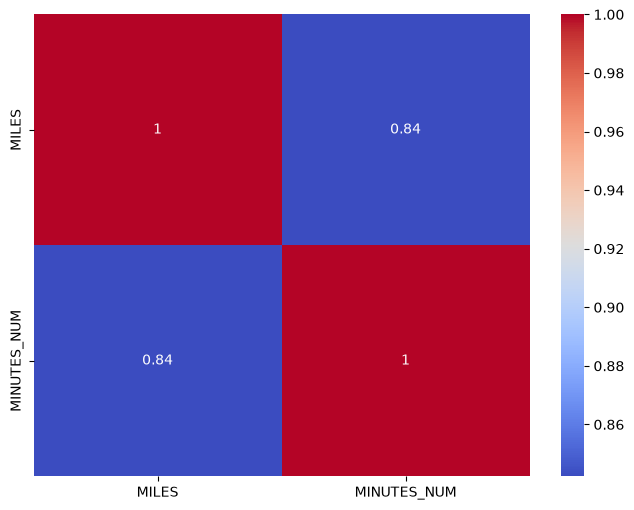

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(df[['MILES', 'MINUTES_NUM']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [34]:
df['MONTH'] = pd.DatetimeIndex(df['START_DATE']).month
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,MINUTES,RoundTrips,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,0 days 00:06:00,Yes,1
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Meal/Entertain,0 days 00:12:00,Yes,1
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,0 days 00:13:00,Yes,1
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,0 days 00:14:00,Yes,1
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,0 days 01:07:00,No,1
...,...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,0 days 00:07:00,Yes,12
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,0 days 00:18:00,No,12
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,0 days 00:35:00,Yes,12
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,0 days 00:18:00,No,12


In [35]:
def month(x) :
    if x['MONTH'] == 1 :
        return ("Jan")
    elif x['MONTH'] == 2 :
        return ("Feb")
    elif x['MONTH'] == 3 :
        return ("Mar")
    elif x['MONTH'] == 4 :
        return ("Apr")
    elif x['MONTH'] == 5 :
        return ("May")
    elif x['MONTH'] == 6 :
        return ("Jun")
    elif x['MONTH'] == 7 :
        return ("Jul")
    elif x['MONTH'] == 8 :
        return ("Aug")
    elif x['MONTH'] == 9 :
        return ("Sep")
    elif x['MONTH'] == 10 :
        return ("Oct")
    elif x['MONTH'] == 11 :
        return ("Nov")
    elif x['MONTH'] == 12 :
        return ("Dec")

In [36]:
df['MONTH']

0        1
1        1
2        1
3        1
4        1
        ..
1150    12
1151    12
1152    12
1153    12
1154    12
Name: MONTH, Length: 1155, dtype: int32

In [37]:
df['MONTHS'] = df.apply(month, axis = 1)
# Pass a list of the exact column names you want to remove to the 'columns' parameter
#df = df.drop(columns=['Monhs', 'Months', 'Month', 'MONTH'])
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,MINUTES,RoundTrips,MONTH,MONTHS
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,0 days 00:06:00,Yes,1,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Meal/Entertain,0 days 00:12:00,Yes,1,Jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,0 days 00:13:00,Yes,1,Jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,0 days 00:14:00,Yes,1,Jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,0 days 01:07:00,No,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,0 days 00:07:00,Yes,12,Dec
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,0 days 00:18:00,No,12,Dec
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,0 days 00:35:00,Yes,12,Dec
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,0 days 00:18:00,No,12,Dec


<Axes: xlabel='MONTHS', ylabel='count'>

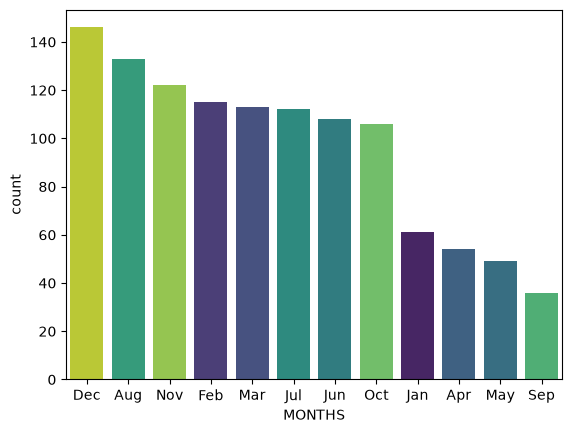

In [38]:
sns.countplot(data = df, order = df['MONTHS'].value_counts().index, x = 'MONTHS',
            hue='MONTHS',       # Assign the x variable to hue
            palette='viridis')  # Choose your color theme here

<Axes: xlabel='MINUTES', ylabel='MILES'>

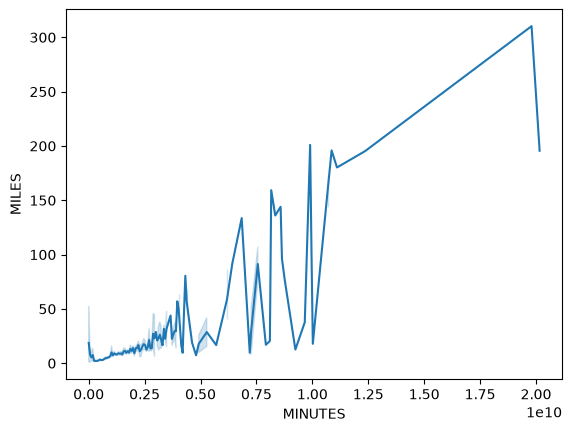

In [39]:
sns.lineplot(data = df, x = 'MINUTES', y = 'MILES')

In [40]:
df.head()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,MINUTES,RoundTrips,MONTH,MONTHS
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,0 days 00:06:00,Yes,1,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Meal/Entertain,0 days 00:12:00,Yes,1,Jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,0 days 00:13:00,Yes,1,Jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,0 days 00:14:00,Yes,1,Jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,0 days 01:07:00,No,1,Jan


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Meal/Entertain'),
  Text(1, 0, 'Errand/Supplies'),
  Text(2, 0, 'Meeting'),
  Text(3, 0, 'Customer Visit'),
  Text(4, 0, 'Temporary Site'),
  Text(5, 0, 'Between Offices'),
  Text(6, 0, 'Charity ($)'),
  Text(7, 0, 'Commute'),
  Text(8, 0, 'Moving'),
  Text(9, 0, 'Airport/Travel')])

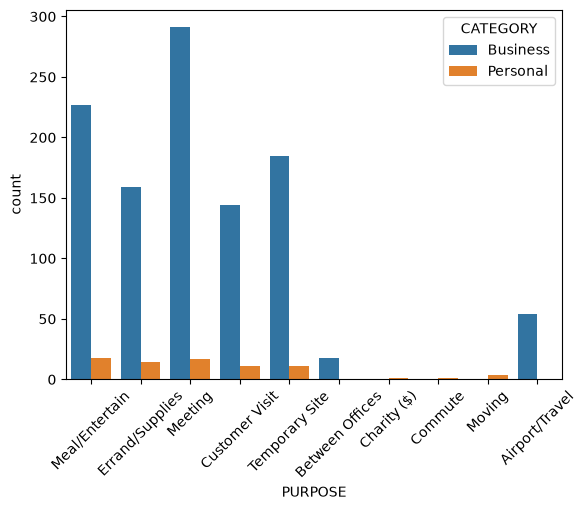

In [41]:
sns.countplot(data = df, x = 'PURPOSE', hue = 'CATEGORY')
plt.xticks(rotation = 45)

## Final Conclusion
1. In december higher number of trips were booked.
2. More buisness trips are booked from uber
3. Commute, Moving, Chaarity are only personal use
4. Offices and Airport / Travel are only for buisness trips
5. Seasonal Pattern  / Festival / Holidays will also impact cab booking (based on monthly analysis)
6. Some round trips are observed in the data
7. Majority of the trips were booked for Meal / Entertain, Meeting and Temporary Site visits.
8. Time of trips increase as miles increase
9. Most frequent Start and Stop points are Cary

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   START_DATE  1155 non-null   datetime64[us] 
 1   END_DATE    1155 non-null   datetime64[us] 
 2   CATEGORY    1155 non-null   str            
 3   START       1155 non-null   str            
 4   STOP        1155 non-null   str            
 5   MILES       1155 non-null   float64        
 6   PURPOSE     1155 non-null   str            
 7   MINUTES     1155 non-null   timedelta64[us]
 8   RoundTrips  1155 non-null   str            
 9   MONTH       1155 non-null   int32          
 10  MONTHS      1155 non-null   str            
dtypes: datetime64[us](2), float64(1), int32(1), str(6), timedelta64[us](1)
memory usage: 145.4 KB


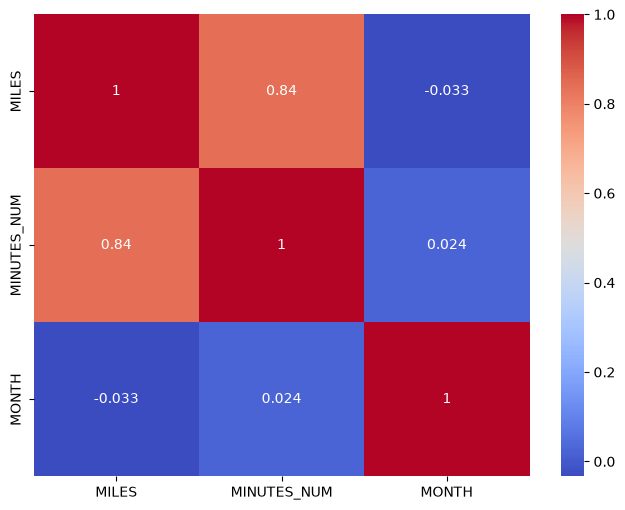

In [ ]:
# Extracts the total seconds from the timedelta and divides by 60 to get standard float minutes
df['MINUTES_NUM'] = df['MINUTES'].dt.total_seconds() / 60

plt.figure(figsize=(8, 6))
# We will use our new numeric column, plus MILES and MONTH
sns.heatmap(df[['MILES', 'MINUTES_NUM', 'MONTH']].corr(), annot=True, cmap='coolwarm')
plt.show()